In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, ks_2samp

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

In [11]:
# Ваши данные (длительность пребывания в формате минуты:секунды)
data_raw = """
0:07
0:17
0:09
0:10
0:20
0:04
0:11
0:04
0:18
0:21
0:04
0:04
0:04
0:18
0:04
0:05
0:20
0:11
0:04
0:12
0:04
0:10
0:04
0:09
0:17
0:18
0:11
0:04
0:04
0:04
0:04
0:12
0:12
0:06
0:20
0:20
0:08
0:04
0:04
0:04
0:10
0:04
0:04
0:09
0:09
0:07
0:04
0:12
0:20
0:17
0:04
0:12
0:04
0:04
0:04
0:20
0:19
0:10
0:04
0:04
0:09
0:04
0:04
0:04
0:06
0:17
0:09
0:07
0:04
0:20
0:18
0:04
0:11
0:04
0:04
0:04
0:04
0:08
0:10
0:09
0:09
0:11
0:08
0:20
0:04
0:11
0:05
0:20
0:04
0:10
0:04
0:11
0:12
0:04
0:04
0:05
0:07
0:09
0:07
0:09
"""

# Преобразуем строки в секунды (например, "0:07" → 7 секунд)
def time_to_seconds(time_str):
    time_str = time_str.strip()
    if ':' in time_str:
        parts = time_str.split(':')
        minutes = int(parts[0])
        seconds = int(parts[1])
        return minutes * 60 + seconds
    else:
        return int(time_str)

# Парсим все значения
data_V = np.array([time_to_seconds(x) for x in data_raw.strip().split()])

print(f"Загружено {len(data_V)} значений")
print(f"Первые 10 значений (в секундах): {data_V[:10]}")
print(f"Первые 10 значений (в формате мм:сс): {[f'{x//60}:{x%60:02d}' for x in data_V[:10]]}")
print(f"\nОсновные статистики:")
print(f"  Среднее: {np.mean(data_V):.2f} сек = {np.mean(data_V)//60:.0f}:{np.mean(data_V)%60:02.0f}")
print(f"  Медиана: {np.median(data_V):.2f} сек")
print(f"  Минимум: {np.min(data_V)} сек")
print(f"  Максимум: {np.max(data_V)} сек")

Загружено 100 значений
Первые 10 значений (в секундах): [ 7 17  9 10 20  4 11  4 18 21]
Первые 10 значений (в формате мм:сс): ['0:07', '0:17', '0:09', '0:10', '0:20', '0:04', '0:11', '0:04', '0:18', '0:21']

Основные статистики:
  Среднее: 9.01 сек = 0:09
  Медиана: 8.00 сек
  Минимум: 4 сек
  Максимум: 21 сек


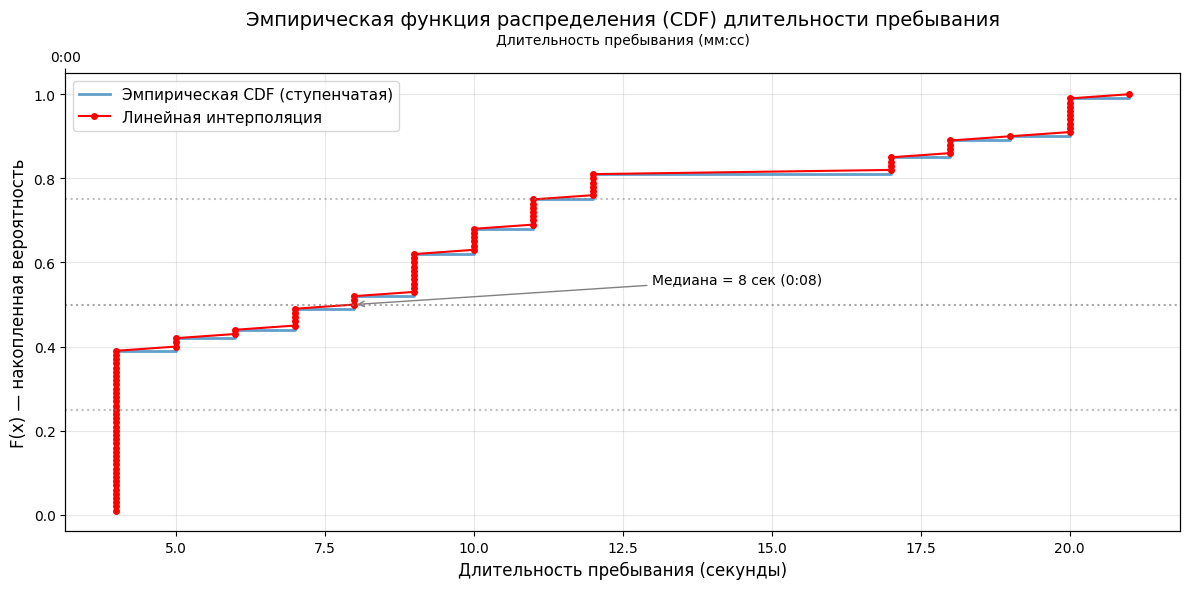

Аппроксимация выполнена методом линейной интерполяции между точками ECDF.


In [18]:
# Сортируем данные
sorted_V = np.sort(data_V)
n_V = len(sorted_V)

# Эмпирическая функция распределения (ECDF)
ecdf_y = np.arange(1, n_V + 1) / n_V

# Построение графика
plt.figure(figsize=(12, 6))

# Ступенчатая ECDF
plt.step(sorted_V, ecdf_y, where='post', 
         linewidth=2, alpha=0.7, label='Эмпирическая CDF (ступенчатая)')

# Линейная интерполяция (соединяем точки отрезками)
plt.plot(sorted_V, ecdf_y, 'o-', markersize=4, 
         color='red', linewidth=1.5, label='Линейная интерполяция')

plt.title('Эмпирическая функция распределения (CDF) длительности пребывания', fontsize=14)
plt.xlabel('Длительность пребывания (секунды)', fontsize=12)
plt.ylabel('F(x) — накопленная вероятность', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Добавим линии для квартилей
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7, label='Медиана')
plt.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=0.75, color='gray', linestyle=':', alpha=0.5)

# Подпись медианы (ИСПРАВЛЕНО: преобразуем в int)
median_val = np.median(data_V)
median_int = int(median_val)  # преобразуем в целое число
plt.annotate(f'Медиана = {median_int} сек ({median_int//60}:{median_int%60:02d})', 
             xy=(median_val, 0.5), xytext=(median_val + 5, 0.55),
             arrowprops=dict(arrowstyle='->', color='gray'))

# Добавим вторую ось X в формате мм:сс
ax2 = plt.gca().twiny()
ax2.set_xlim(plt.gca().get_xlim())
ax2.set_xticks(np.arange(0, max(sorted_V)+5, 30))
ax2.set_xticklabels([f'{int(x)//60}:{int(x)%60:02d}' for x in np.arange(0, max(sorted_V)+5, 30)])
ax2.set_xlabel('Длительность пребывания (мм:сс)', fontsize=10)

plt.tight_layout()
plt.show()

print("Аппроксимация выполнена методом линейной интерполяции между точками ECDF.")

Пункт 3. Точечные и интервальные оценки (доверительная вероятность 0.95)

Объём выборки: n = 100

Точечные оценки:
  Выборочное среднее (x̄) = 9.0100 сек = 0:09
  Выборочная дисперсия (s²) = 30.9595 сек²
  Среднеквадратическое отклонение (s) = 5.5641 сек

95% доверительный интервал для математического ожидания:
  t(α/2, n-1) = 1.9842
  Погрешность (Δ) = 1.1040 сек
  Интервал: [7.9060; 10.1140] сек
  В формате мм:сс: [0:08; 0:10]


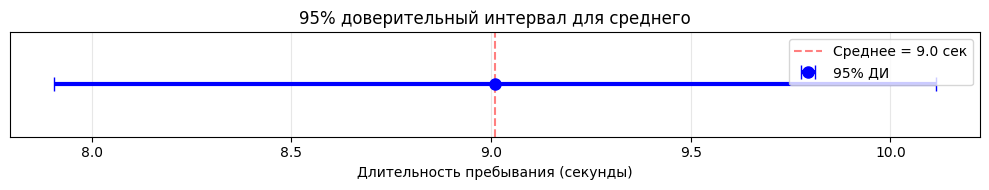

In [19]:
# Точечные оценки
mean_V = np.mean(data_V)
var_V = np.var(data_V, ddof=1)      # несмещённая дисперсия
std_V = np.std(data_V, ddof=1)      # несмещённое СКО
n_V = len(data_V)

# 95% доверительный интервал для среднего
conf_level = 0.95
alpha = 1 - conf_level
t_crit = t.ppf(1 - alpha/2, df=n_V - 1)
margin = t_crit * std_V / np.sqrt(n_V)

ci_lower = mean_V - margin
ci_upper = mean_V + margin

print("=" * 60)
print("Пункт 3. Точечные и интервальные оценки (доверительная вероятность 0.95)")
print("=" * 60)
print(f"\nОбъём выборки: n = {n_V}")
print(f"\nТочечные оценки:")
print(f"  Выборочное среднее (x̄) = {mean_V:.4f} сек = {mean_V//60:.0f}:{mean_V%60:02.0f}")
print(f"  Выборочная дисперсия (s²) = {var_V:.4f} сек²")
print(f"  Среднеквадратическое отклонение (s) = {std_V:.4f} сек")
print(f"\n95% доверительный интервал для математического ожидания:")
print(f"  t(α/2, n-1) = {t_crit:.4f}")
print(f"  Погрешность (Δ) = {margin:.4f} сек")
print(f"  Интервал: [{ci_lower:.4f}; {ci_upper:.4f}] сек")
print(f"  В формате мм:сс: [{ci_lower//60:.0f}:{ci_lower%60:02.0f}; {ci_upper//60:.0f}:{ci_upper%60:02.0f}]")

# Визуализация доверительного интервала
plt.figure(figsize=(10, 2))
plt.errorbar(x=mean_V, y=0, xerr=margin, fmt='o', capsize=5, 
             color='blue', markersize=8, elinewidth=3, label='95% ДИ')
plt.axvline(mean_V, color='red', linestyle='--', alpha=0.5, label=f'Среднее = {mean_V:.1f} сек')
plt.yticks([])
plt.xlabel('Длительность пребывания (секунды)')
plt.title('95% доверительный интервал для среднего')
plt.legend()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [14]:
# Данные задачи Б (из вашего файла)
data_B_raw = """
109,42 92,59 119,53 103,76 101,44 91,56 111,74 102,48 92,21
99,46 109,18 99,83 99,14 101,31 96,71 95,22 90,72 93,69
98,72 82,92 101,83 115,43 98,13 117,48 117,92 99,41 113,81
100,61 104,72 89,11 95,59 95,19 113,46 89,88 100,54 101,94
105,84 102,65 114,57 101,74 108,83 87,57 101,19 95,69 91,44
87,86 98,34 97,15 103,55 92,14 112,04 88,44 98,49 100,04
98,54 110,62 112,23 101,63 100,59 88,29 109,58 107,14 107,21
91,11 116,73 101,95 111,50 101,52 101,83 115,43 100,31 112,57
100,42 89,22 94,54 102,23 108,99 104,81 90,85 100,61 104,72
107,57 113,61 108,12 107,38 101,38 99,22 110,24 99,14 101,31
"""
data_B = np.array([float(x.replace(',', '.')) for x in data_B_raw.split()])

print(f"Загружено {len(data_B)} значений для задачи Б")
print(f"Статистики задачи Б:")
print(f"  Среднее = {np.mean(data_B):.4f}")
print(f"  СКО = {np.std(data_B, ddof=1):.4f}")
print(f"  Мин = {np.min(data_B):.4f}, Макс = {np.max(data_B):.4f}")

Загружено 90 значений для задачи Б
Статистики задачи Б:
  Среднее = 101.8599
  СКО = 8.2149
  Мин = 82.9200, Макс = 119.5300


In [15]:
# Двухвыборочный критерий Колмогорова-Смирнова
ks_stat, ks_pvalue = ks_2samp(data_B, data_V)

print("=" * 60)
print("Пункт 4. Критерий Колмогорова-Смирнова")
print("=" * 60)
print(f"\nСтатистика KS (D-статистика): {ks_stat:.4f}")
print(f"p-значение: {ks_pvalue:.6f}")

alpha_ks = 0.05
print(f"\nУровень значимости α = {alpha_ks}")

# Гипотеза
print("\nГипотеза H₀: распределения выборок из задачи Б и задачи В одинаковы.")
print("Альтернатива H₁: распределения различаются.")

print(f"\np-значение = {ks_pvalue:.6f}")

if ks_pvalue > alpha_ks:
    print("\n✅ p-значение > α → H₀ НЕ ОТВЕРГАЕТСЯ.")
    print("→ Распределения выборок статистически НЕ РАЗЛИЧАЮТСЯ.")
    print("→ Данные из задачи В соответствуют распределению данных из задачи Б.")
else:
    print("\n❌ p-значение ≤ α → H₀ ОТВЕРГАЕТСЯ.")
    print("→ Распределения выборок статистически ЗНАЧИМО РАЗЛИЧАЮТСЯ.")
    print("→ Данные из задачи В имеют другое распределение, чем данные из задачи Б.")

Пункт 4. Критерий Колмогорова-Смирнова

Статистика KS (D-статистика): 1.0000
p-значение: 0.000000

Уровень значимости α = 0.05

Гипотеза H₀: распределения выборок из задачи Б и задачи В одинаковы.
Альтернатива H₁: распределения различаются.

p-значение = 0.000000

❌ p-значение ≤ α → H₀ ОТВЕРГАЕТСЯ.
→ Распределения выборок статистически ЗНАЧИМО РАЗЛИЧАЮТСЯ.
→ Данные из задачи В имеют другое распределение, чем данные из задачи Б.


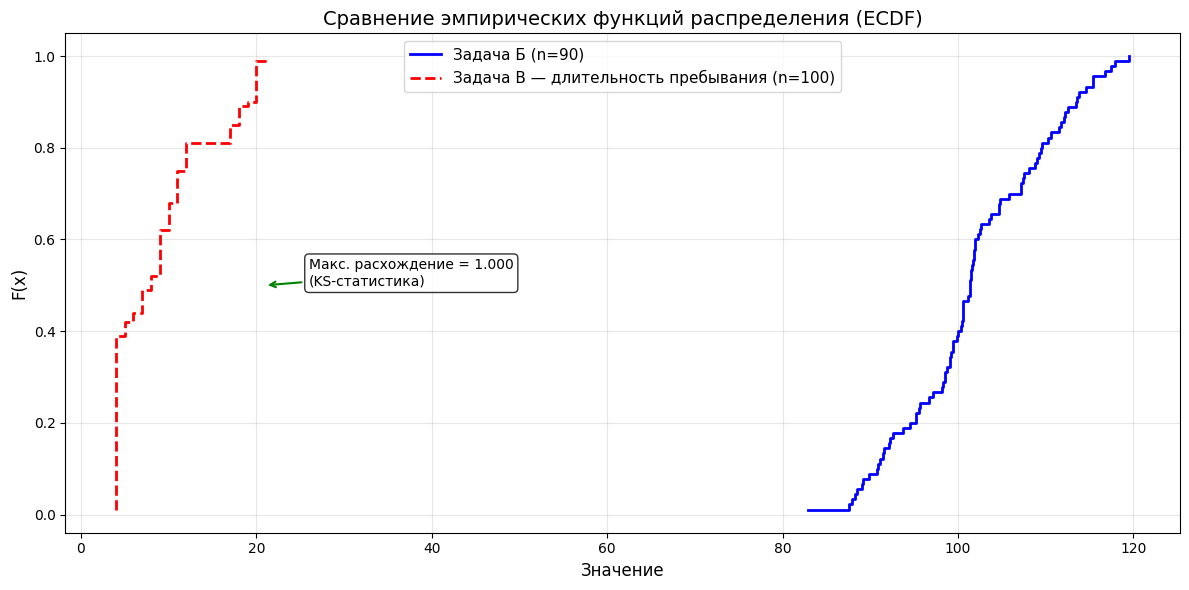

In [20]:
# Функция для построения ECDF
def plot_ecdf(data, label, color, linestyle='-', linewidth=2):
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(data) + 1) / len(data)
    plt.step(sorted_data, ecdf, where='post', label=label, 
             color=color, linewidth=linewidth, linestyle=linestyle)

plt.figure(figsize=(12, 6))

plot_ecdf(data_B, f'Задача Б (n={len(data_B)})', 'blue', '-', 2)
plot_ecdf(data_V, f'Задача В — длительность пребывания (n={len(data_V)})', 'red', '--', 2)

plt.title('Сравнение эмпирических функций распределения (ECDF)', fontsize=14)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('F(x)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Найдём точку максимального расхождения
all_values = np.sort(np.concatenate([data_B, data_V]))
ecdf_B = np.array([np.mean(data_B <= x) for x in all_values])
ecdf_V = np.array([np.mean(data_V <= x) for x in all_values])
max_diff = np.max(np.abs(ecdf_B - ecdf_V))
max_diff_point = all_values[np.argmax(np.abs(ecdf_B - ecdf_V))]

plt.annotate(f'Макс. расхождение = {max_diff:.3f}\n(KS-статистика)', 
             xy=(max_diff_point, (ecdf_B[np.argmax(np.abs(ecdf_B - ecdf_V))] + 
                                   ecdf_V[np.argmax(np.abs(ecdf_B - ecdf_V))])/2),
             xytext=(max_diff_point + 5, 0.5),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

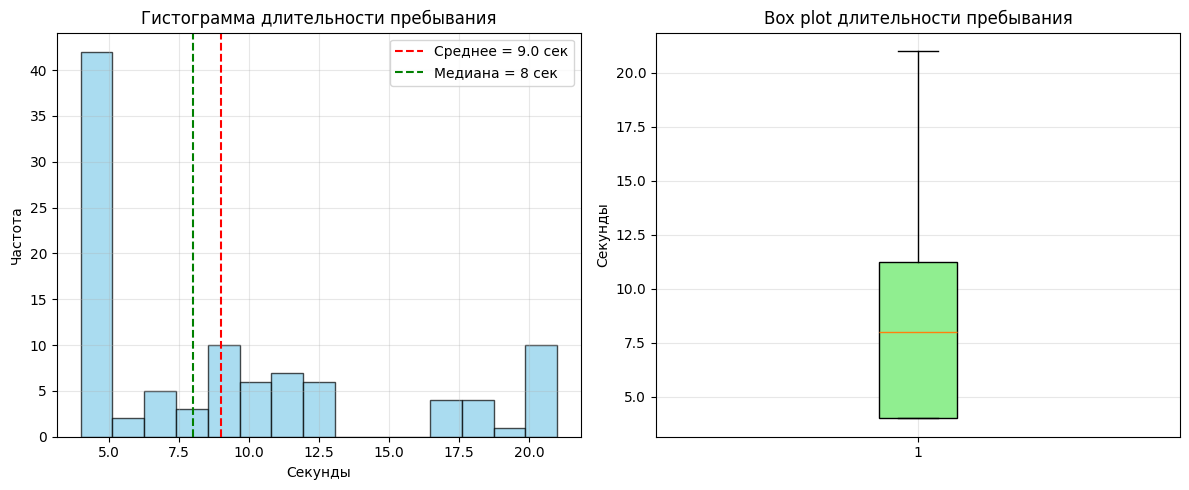


Дополнительные статистики:
  Q1 (25%): 4 сек
  Q3 (75%): 11 сек
  IQR: 7 сек


In [21]:
# Гистограмма длительности пребывания
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data_V, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(mean_V, color='red', linestyle='--', label=f'Среднее = {mean_V:.1f} сек')
plt.axvline(median_val, color='green', linestyle='--', label=f'Медиана = {median_val:.0f} сек')
plt.title('Гистограмма длительности пребывания')
plt.xlabel('Секунды')
plt.ylabel('Частота')
plt.legend()
plt.grid(alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
box = plt.boxplot(data_V, vert=True, patch_artist=True)
box['boxes'][0].set_facecolor('lightgreen')
plt.title('Box plot длительности пребывания')
plt.ylabel('Секунды')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\nДополнительные статистики:")
print(f"  Q1 (25%): {np.percentile(data_V, 25):.0f} сек")
print(f"  Q3 (75%): {np.percentile(data_V, 75):.0f} сек")
print(f"  IQR: {np.percentile(data_V, 75) - np.percentile(data_V, 25):.0f} сек")